In [28]:
import torch
from torch import nn
import matplotlib as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from torch.nn import functional as F

In [29]:
pd_bank_data_train = pd.read_csv("train.csv")
pd_bank_data_test = pd.read_csv("test.csv")

In [30]:
print(pd_bank_data_train.shape)
pd_bank_data_train.head()

(165034, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [31]:
# добавляем новые столбцы в test
pd_bank_data_test['BalanceSalaryRatio'] = pd_bank_data_test['Balance'] / (pd_bank_data_test['EstimatedSalary'] + 1)
pd_bank_data_test['CreditScoreAge'] = pd_bank_data_test['CreditScore'] / pd_bank_data_test['Age']
pd_bank_data_test['TenureAge'] = pd_bank_data_test['Tenure'] / pd_bank_data_test['Age']
pd_bank_data_test['IsActiveHighBalance'] = \
((pd_bank_data_test['IsActiveMember'] == 1) & (pd_bank_data_test['Balance'] > pd_bank_data_test['Balance'].median())).astype(int)

# добавляем новые столбцы в train
pd_bank_data_train['BalanceSalaryRatio'] = pd_bank_data_train['Balance'] / (pd_bank_data_train['EstimatedSalary'] + 1)
pd_bank_data_train['CreditScoreAge'] = pd_bank_data_train['CreditScore'] / pd_bank_data_train['Age']
pd_bank_data_train['TenureAge'] = pd_bank_data_train['Tenure'] / pd_bank_data_train['Age']
pd_bank_data_train['IsActiveHighBalance'] = \
((pd_bank_data_train['IsActiveMember'] == 1) & (pd_bank_data_train['Balance'] > pd_bank_data_train['Balance'].median())).astype(int)

pd_bank_data_train = pd_bank_data_train[[c for c in pd_bank_data_train.columns if c != 'Exited'] + ['Exited']]

print(pd_bank_data_train.shape)
print(pd_bank_data_test.shape)
pd_bank_data_train.head()

(165034, 18)
(110023, 17)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,CreditScoreAge,TenureAge,IsActiveHighBalance,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0.000000,20.242424,0.090909,0,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0.000000,19.000000,0.030303,0,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0.000000,16.950000,0.250000,0,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,1.760634,17.088235,0.058824,1,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0.000000,21.696970,0.151515,0,0


In [32]:
print("Доля тех, кто ушел из банка", pd_bank_data_train["Exited"].sum()/pd_bank_data_train.shape[0])

Доля тех, кто ушел из банка 0.21159882206090866


In [33]:
for col in pd_bank_data_train.columns:
    print(f"{col:<20} | {pd_bank_data_train[col].isna().sum()} NULL objects | DATA TYPE: {pd_bank_data_train[col].dtypes}")

id                   | 0 NULL objects | DATA TYPE: int64
CustomerId           | 0 NULL objects | DATA TYPE: int64
Surname              | 0 NULL objects | DATA TYPE: object
CreditScore          | 0 NULL objects | DATA TYPE: int64
Geography            | 0 NULL objects | DATA TYPE: object
Gender               | 0 NULL objects | DATA TYPE: object
Age                  | 0 NULL objects | DATA TYPE: float64
Tenure               | 0 NULL objects | DATA TYPE: int64
Balance              | 0 NULL objects | DATA TYPE: float64
NumOfProducts        | 0 NULL objects | DATA TYPE: int64
HasCrCard            | 0 NULL objects | DATA TYPE: float64
IsActiveMember       | 0 NULL objects | DATA TYPE: float64
EstimatedSalary      | 0 NULL objects | DATA TYPE: float64
BalanceSalaryRatio   | 0 NULL objects | DATA TYPE: float64
CreditScoreAge       | 0 NULL objects | DATA TYPE: float64
TenureAge            | 0 NULL objects | DATA TYPE: float64
IsActiveHighBalance  | 0 NULL objects | DATA TYPE: int64
Exited      

In [34]:
# 0 - удалить
# 1 - не менять
# 2 - отделить по классам
to_do_column = [ 0, #id
                 0, #CustomerId
                 0, #Surname
                 1, #CreditScore
                 2, #Geography
                 2, #Gender
                 1, #Age
                 1, #Tensure
                 1, #Balance
                 1, #NumOfProducts
                 1, #HasCrCard
                 1, #IsActiveMember
                 1, #EstimatedSalary
                 1, #BalanceSalaryRatio
                 1, #CreditScoreAge
                 1, #TenureAge
                 1, #IsActiveHighBalance
                 
]

np_to_do_column = np.array(to_do_column)
print(np_to_do_column.shape)

(17,)


In [35]:
col = "Gender"
print(pd_bank_data_train[col])
print(pd_bank_data_train[col].unique())

0           Male
1           Male
2           Male
3           Male
4           Male
           ...  
165029    Female
165030      Male
165031      Male
165032    Female
165033      Male
Name: Gender, Length: 165034, dtype: object
['Male' 'Female']


In [36]:
train_pd = pd_bank_data_train
test_pd = pd_bank_data_test

header_new = np.array([])

np_data_concatenate_numeric = np.zeros((train_pd.shape[0], 1))
np_data_concatenate_category = np.zeros((train_pd.shape[0], 1))

counter = 0
counter_2 = 0

for col, i in zip(train_pd.columns, range(np_to_do_column.shape[0])):
    print(f"i = {i}")
    if (np_to_do_column[i] == 0):
        # удаляем столбец. Он не нужен. А лучше сказать по другому - мы его не будет вставлять в новый numpy array
        print(f"Column name: {col}")
        print("Column not included \n")        
        continue

    elif (np_to_do_column[i] == 1):
        # копируем из pandas и вставляем в numpy array
        print(f"Column name: {col}")
        counter += 1 # для проверки
        
        np_add = train_pd[col].fillna(0).to_numpy()[:, None] # превращаем NaN в нули
        np_data_concatenate_numeric = np.concatenate((np_data_concatenate_numeric, np_add), axis = 1)
        nan_sum = np.isnan(np_add).sum()
        null_num = train_pd[col].isnull().sum()
        print(f"Null num: {null_num}") # для проверки
        print(f"NaN  num: {nan_sum} \n") # для проверки. Если показывает 0 - все верно

        # добавляем названия в header
        header_new = np.append(header_new, col)

    elif (np_to_do_column[i] == 2):
        print(f"Column name: {col}")

        null_num = train_pd[col].isnull().sum()
        print(f"Null num: {null_num}") # для проверки
        unique_data_column = train_pd[col].unique()
        print("Unique data types", unique_data_column.shape[0])
        
        train_pd[col] = train_pd[col].fillna("None") # убираем NULL
        null_num = train_pd[col].isnull().sum()
        print(f"Null num after changed: {null_num}") # для проверки 
        unique_data_column = train_pd[col].unique()
        print("Unique data types after changed", unique_data_column.shape[0]) # для проверки 

        counter_2 += unique_data_column.shape[0] # для проверки
        
        # добавляем в наш массив
        np_add = np.zeros((train_pd.shape[0], unique_data_column.shape[0])) # превращаем NaN в нули
        print("shape", np_add.shape)
        
        for i_new in range(train_pd.shape[0]):
            for j_new in range(unique_data_column.shape[0]):
                if (train_pd.loc[i_new, col] == unique_data_column[j_new]):
                    np_add[i_new, j_new] = 1 # этот элемент есть
                else:
                    continue # этого элемента нет - обнуляем

        np_data_concatenate_category = np.concatenate((np_data_concatenate_category, np_add), axis = 1)

        # добавляем названия в header
        for i in range(unique_data_column.shape[0]):
            head = str(unique_data_column[i]) + "_" + str(col)
            header_new = np.append(header_new, head)

        print("\n")

np_data_concatenate_numeric = np_data_concatenate_numeric[:, :-1] # убираем первый пустой столбец, который добавили в самом начале
np_data_concatenate_category = np_data_concatenate_category[:, :-1] 

i = 0
Column name: id
Column not included 

i = 1
Column name: CustomerId
Column not included 

i = 2
Column name: Surname
Column not included 

i = 3
Column name: CreditScore
Null num: 0
NaN  num: 0 

i = 4
Column name: Geography
Null num: 0
Unique data types 3
Null num after changed: 0
Unique data types after changed 3
shape (165034, 3)


i = 5
Column name: Gender
Null num: 0
Unique data types 2
Null num after changed: 0
Unique data types after changed 2
shape (165034, 2)


i = 6
Column name: Age
Null num: 0
NaN  num: 0 

i = 7
Column name: Tenure
Null num: 0
NaN  num: 0 

i = 8
Column name: Balance
Null num: 0
NaN  num: 0 

i = 9
Column name: NumOfProducts
Null num: 0
NaN  num: 0 

i = 10
Column name: HasCrCard
Null num: 0
NaN  num: 0 

i = 11
Column name: IsActiveMember
Null num: 0
NaN  num: 0 

i = 12
Column name: EstimatedSalary
Null num: 0
NaN  num: 0 

i = 13
Column name: BalanceSalaryRatio
Null num: 0
NaN  num: 0 

i = 14
Column name: CreditScoreAge
Null num: 0
NaN  num: 0 

i

In [37]:
np_data_concatenate = np.concatenate((np_data_concatenate_numeric, np_data_concatenate_category), axis = 1)
#np_data_concatenate = np.copy(np_data_concatenate_numeric)

print("Численные признаки      =", np_data_concatenate_numeric.shape[1], " == ", counter)
print("Категориальные признаки =", np_data_concatenate_category.shape[1], " == ", counter_2)
print("Размер данных матрицы   =", np_data_concatenate.shape)
print("Есть ли пропуски        =", np.isnan(np_data_concatenate).any())
print("Размер header           =", header_new.shape[0])

Численные признаки      = 12  ==  12
Категориальные признаки = 5  ==  5
Размер данных матрицы   = (165034, 17)
Есть ли пропуски        = False
Размер header           = 17


In [38]:
# запоминаем header!
header_one = np.copy(header_new)
np_data_concatenate_one = np.copy(np_data_concatenate)

In [39]:
x_data = np_data_concatenate
y_data = train_pd["Exited"].to_numpy()

In [40]:
x_train_np, x_test_np, y_train_np, y_test_np = train_test_split(x_data, y_data, test_size = 0.25)

In [41]:
# нормируем
scaler = StandardScaler()
x_train_scaled_np = scaler.fit_transform(x_train_np)
x_test_scaled_np = scaler.transform(x_test_np)

Теперь будем решать через Torch и нейронные сети

In [42]:
x_train_scaled_tensor = torch.tensor(x_train_scaled_np, dtype=torch.float32)
x_test_scaled_tensor = torch.tensor(x_test_scaled_np, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32)

In [43]:
# создаем модель
model = nn.Sequential()

input_dim = np_data_concatenate.shape[1]
layer_1_nn_number = 64
layer_2_nn_number = 32
layer_3_nn_number = 16

# Входной слой (input_dim = сколько признаков, например 15)
model.add_module("layer1", nn.Linear(input_dim, layer_1_nn_number))
model.add_module("batchnorm1", nn.BatchNorm1d(layer_1_nn_number))
model.add_module("activation1", nn.ReLU())
model.add_module("dropout1", nn.Dropout(0.3))

# Второй слой
model.add_module("layer2", nn.Linear(layer_1_nn_number, layer_2_nn_number))
model.add_module("batchnorm2", nn.BatchNorm1d(layer_2_nn_number))
model.add_module("activation2", nn.ReLU())
model.add_module("dropout2", nn.Dropout(0.2))

# Третий слой
model.add_module("layer3", nn.Linear(layer_2_nn_number, layer_3_nn_number))
model.add_module("batchnorm3", nn.BatchNorm1d(layer_3_nn_number))
model.add_module("activation3", nn.ReLU())

# Выходной слой
model.add_module("output", nn.Linear(layer_3_nn_number, 1))
model.add_module("sigmoid", nn.Sigmoid())

In [44]:
print(model)

Sequential(
  (layer1): Linear(in_features=17, out_features=64, bias=True)
  (batchnorm1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (activation1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (batchnorm2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (activation2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (layer3): Linear(in_features=32, out_features=16, bias=True)
  (batchnorm3): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (activation3): ReLU()
  (output): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [45]:
dataset = TensorDataset(x_train_scaled_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [46]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
#scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.50) 

In [47]:
loss_history = []
epoch = 10

for i_ep in range(epoch):
    for x_batch, y_batch in dataloader:
        # predict probabilities
        y_predicted = model(x_batch)[:, 0]  # YOUR CODE HERE

        crossentropy = F.binary_cross_entropy(y_predicted, y_batch, reduction = "none") # YOUR CODE HERE
        loss = torch.mean(crossentropy) # YOUR CODE HERE

        # compute gradients
        loss.backward()

        # Adam step
        opt.step()

        # clear gradients
        opt.zero_grad()

        loss_history.append(loss.data.numpy())

    print(f"{i_ep:<2} step from {epoch} finished")
    print(f"Loss = {loss_history[-1]:.4f} \n")  # посмотреть текущий lr
    #print(f"the last learning rate {scheduler.get_last_lr()[0]:.6f}")  # посмотреть текущий lr
    #scheduler.step()

0  step from 10 finished
Loss = 0.4040 

1  step from 10 finished
Loss = 0.2538 

2  step from 10 finished
Loss = 0.2921 

3  step from 10 finished
Loss = 0.3506 

4  step from 10 finished
Loss = 0.3078 

5  step from 10 finished
Loss = 0.3530 

6  step from 10 finished
Loss = 0.2487 

7  step from 10 finished
Loss = 0.3006 

8  step from 10 finished
Loss = 0.2612 

9  step from 10 finished
Loss = 0.3712 



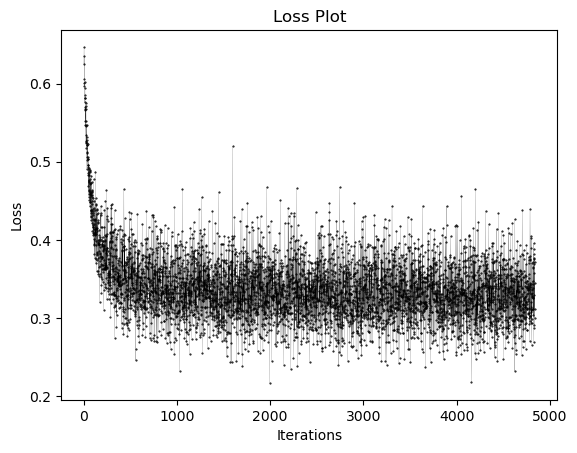

In [48]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(loss_history) + 1), loss_history, ".-", color = "black", linewidth = 0.1, markersize = 1.0)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()

In [52]:
y_pred_train = model(x_train_scaled_tensor)[:, 0]  # YOUR CODE HERE
y_pred_test = model(x_test_scaled_tensor)[:, 0]  # YOUR CODE HERE

y_pred_train_np = model(x_train_scaled_tensor)[:, 0].detach().cpu().numpy()
y_pred_test_np = model(x_test_scaled_tensor)[:, 0].detach().cpu().numpy()

print("ROC AUC TRAIN: \t", roc_auc_score(y_train_np, y_pred_train_np))
print("ROC AUC TEST: \t", roc_auc_score(y_test_np, y_pred_test_np))

ROC AUC TRAIN: 	 0.8839287894445647
ROC AUC TEST: 	 0.8806093508299566


In [45]:
model.eval()
with torch.no_grad():
    train_pred = model(x_train_scaled_tensor)[:, 0]
    test_pred = model(x_test_scaled_tensor)[:, 0]
    print(f"Train BCE: {F.binary_cross_entropy(train_pred, y_train_tensor):.4f}")
    print(f"Test BCE: {F.binary_cross_entropy(test_pred, y_test_tensor):.4f}")

Train BCE: 0.3238
Test BCE: 0.3211


In [46]:
train_acc = ((train_pred > 0.5).float() == y_train_tensor).float().mean()
test_acc = ((test_pred > 0.5).float() == y_test_tensor).float().mean()
print(f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Train Acc: 0.8636, Test Acc: 0.8652


In [48]:
y_pred_class = (test_pred > 0.3).cpu().numpy()
y_true = y_test_tensor.cpu().numpy()

print(classification_report(y_true, y_pred_class))

              precision    recall  f1-score   support

         0.0       0.92      0.89      0.90     32548
         1.0       0.63      0.71      0.66      8711

    accuracy                           0.85     41259
   macro avg       0.77      0.80      0.78     41259
weighted avg       0.86      0.85      0.85     41259



Подготовка к отправке данных

In [49]:
train_pd = pd_bank_data_test
#test_pd = pd_bank_data_test

header_new = np.array([])

np_data_concatenate_numeric = np.zeros((train_pd.shape[0], 1))
np_data_concatenate_category = np.zeros((train_pd.shape[0], 1))

counter = 0
counter_2 = 0

for col, i in zip(train_pd.columns, range(np_to_do_column.shape[0])):
    print(f"i = {i}")
    if (np_to_do_column[i] == 0):
        # удаляем столбец. Он не нужен. А лучше сказать по другому - мы его не будет вставлять в новый numpy array
        print(f"Column name: {col}")
        print("Column not included \n")        
        continue

    elif (np_to_do_column[i] == 1):
        # копируем из pandas и вставляем в numpy array
        print(f"Column name: {col}")
        counter += 1 # для проверки
        
        np_add = train_pd[col].fillna(0).to_numpy()[:, None] # превращаем NaN в нули
        np_data_concatenate_numeric = np.concatenate((np_data_concatenate_numeric, np_add), axis = 1)
        nan_sum = np.isnan(np_add).sum()
        null_num = train_pd[col].isnull().sum()
        print(f"Null num: {null_num}") # для проверки
        print(f"NaN  num: {nan_sum} \n") # для проверки. Если показывает 0 - все верно

        # добавляем названия в header
        header_new = np.append(header_new, col)

    elif (np_to_do_column[i] == 2):
        print(f"Column name: {col}")

        null_num = train_pd[col].isnull().sum()
        print(f"Null num: {null_num}") # для проверки
        unique_data_column = train_pd[col].unique()
        print("Unique data types", unique_data_column.shape[0])
        
        train_pd[col] = train_pd[col].fillna("None") # убираем NULL
        null_num = train_pd[col].isnull().sum()
        print(f"Null num after changed: {null_num}") # для проверки 
        unique_data_column = train_pd[col].unique()
        print("Unique data types after changed", unique_data_column.shape[0]) # для проверки 

        counter_2 += unique_data_column.shape[0] # для проверки
        
        # добавляем в наш массив
        np_add = np.zeros((train_pd.shape[0], unique_data_column.shape[0])) # превращаем NaN в нули
        print("shape", np_add.shape)
        
        for i_new in range(train_pd.shape[0]):
            for j_new in range(unique_data_column.shape[0]):
                if (train_pd.loc[i_new, col] == unique_data_column[j_new]):
                    np_add[i_new, j_new] = 1 # этот элемент есть
                else:
                    continue # этого элемента нет - обнуляем

        np_data_concatenate_category = np.concatenate((np_data_concatenate_category, np_add), axis = 1)

        # добавляем названия в header
        for i in range(unique_data_column.shape[0]):
            head = str(unique_data_column[i]) + "_" + str(col)
            header_new = np.append(header_new, head)

        print("\n")

np_data_concatenate_numeric = np_data_concatenate_numeric[:, :-1] # убираем первый пустой столбец, который добавили в самом начале
np_data_concatenate_category = np_data_concatenate_category[:, :-1] 

i = 0
Column name: id
Column not included 

i = 1
Column name: CustomerId
Column not included 

i = 2
Column name: Surname
Column not included 

i = 3
Column name: CreditScore
Null num: 0
NaN  num: 0 

i = 4
Column name: Geography
Null num: 0
Unique data types 3
Null num after changed: 0
Unique data types after changed 3
shape (110023, 3)


i = 5
Column name: Gender
Null num: 0
Unique data types 2
Null num after changed: 0
Unique data types after changed 2
shape (110023, 2)


i = 6
Column name: Age
Null num: 0
NaN  num: 0 

i = 7
Column name: Tenure
Null num: 0
NaN  num: 0 

i = 8
Column name: Balance
Null num: 0
NaN  num: 0 

i = 9
Column name: NumOfProducts
Null num: 0
NaN  num: 0 

i = 10
Column name: HasCrCard
Null num: 0
NaN  num: 0 

i = 11
Column name: IsActiveMember
Null num: 0
NaN  num: 0 

i = 12
Column name: EstimatedSalary
Null num: 0
NaN  num: 0 

i = 13
Column name: BalanceSalaryRatio
Null num: 0
NaN  num: 0 

i = 14
Column name: CreditScoreAge
Null num: 0
NaN  num: 0 

i

In [50]:
np_data_concatenate = np.concatenate((np_data_concatenate_numeric, np_data_concatenate_category), axis = 1)
#np_data_concatenate = np.copy(np_data_concatenate_numeric)

print("Численные признаки      =", np_data_concatenate_numeric.shape[1], " == ", counter)
print("Категориальные признаки =", np_data_concatenate_category.shape[1], " == ", counter_2)
print("Размер данных матрицы   =", np_data_concatenate.shape)
print("Есть ли пропуски        =", np.isnan(np_data_concatenate).any())
print("Размер header           =", header_new.shape[0])

Численные признаки      = 12  ==  12
Категориальные признаки = 5  ==  5
Размер данных матрицы   = (110023, 17)
Есть ли пропуски        = False
Размер header           = 17


In [52]:
# запоминаем header!
header_two = np.copy(header_new)
np_data_concatenate_two = np.copy(np_data_concatenate)

In [54]:
x_send_test = np_data_concatenate_two

In [55]:
# нормируем
scaler = StandardScaler()
x_send_test_scaled_np = scaler.fit_transform(x_send_test)

In [56]:
x_send_test_scaled_tensor = torch.tensor(x_send_test_scaled_np, dtype=torch.float32)

In [61]:
y_pred_send_test = model(x_send_test_scaled_tensor)[:, 0]  
y_pred_send_test_np = y_pred_send_test.detach().cpu().numpy()

In [62]:
# Загружаем тестовые данные (нужны только Id)
test_ids = test_pd['id']

# Создаём DataFrame для сабмита
submission = pd.DataFrame({
    'id': test_ids,
    'Exited': y_pred_send_test_np
})

# Проверяем формат
submission.head()

,id,Exited
0,165034,0.011582
1,165035,0.739485
2,165036,0.014376
3,165037,0.359555
4,165038,0.165133


In [63]:
# Сохраняем в CSV (без индекса!)
submission.to_csv('submission.csv', index=False)